# Flow Matching Implementation Notebook

This notebook has two layers. The first part keeps the original two-dimensional flow-matching example because it makes deterministic transport visible: students can literally see points move from a simple source distribution toward a structured target. The second part implements **Rectified Flow Matching** for FashionMNIST, so the method becomes directly comparable with the VAE, GAN, and diffusion image-generation notebooks.

The two parts should be read together. The toy example explains what the vector field means geometrically. The image example shows how the same idea becomes a realistic generative-model training loop: sample noise and data images, interpolate between them at random times, regress the endpoint velocity with a time-conditioned U-Net, and sample by integrating the learned ODE from noise to image space.

The image-scale implementation is deliberately compact rather than production-scale. It uses FashionMNIST, a small U-Net-like velocity network, and an explicit ODE sampler. The goal is not to claim benchmark quality, but to produce recognizable generated images while keeping the code readable enough for a live teaching session. The FID and KID block follows the same evaluation pattern used in the previous implementation notebooks, so students can compare all model families with the same metric language.

## Imports and a Toy Dataset

To keep the notebook self-contained, we generate a synthetic mixture of circles in the plane. This type of dataset is common in flow-matching demos because it is simple enough to visualize but structured enough that transport is nontrivial.

The dataset choice is deliberate. A unimodal Gaussian target would make the transport problem too easy and visually uninteresting. The two-ring structure forces the learned field to split mass meaningfully, which helps students see that the velocity network is learning geometry rather than merely drifting everything toward one central cluster.

In [2]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(7)
if device.type == "cuda":
    torch.cuda.manual_seed_all(7)

# The example is small enough to visualize directly after a short training run.
batch_size = 512
hidden_dim = 192
time_dim = 96
epochs = 4000
lr = 8e-4


def sample_target(batch_size, device):
    angles = 2 * math.pi * torch.rand(batch_size, device=device)
    radii = torch.where(
        torch.rand(batch_size, device=device) > 0.5,
        torch.full((batch_size,), 2.0, device=device),
        torch.full((batch_size,), 4.0, device=device),
    )
    noise = 0.15 * torch.randn(batch_size, 2, device=device)
    # Two noisy rings give the transport field a visibly multimodal target.
    points = torch.stack([radii * torch.cos(angles), radii * torch.sin(angles)], dim=1)
    return points + noise


def sample_source(batch_size, device):
    return torch.randn(batch_size, 2, device=device)

## Linear Conditional Path

We use the simplest conditional interpolation:
:::{math}
\boldsymbol{x}_t = (1-t)\boldsymbol{x}_0 + t\boldsymbol{x}_1.
:::
Its conditional velocity is constant in time:
:::{math}
\boldsymbol{u}_t(\boldsymbol{x}_t | \boldsymbol{x}_0, \boldsymbol{x}_1) = \boldsymbol{x}_1 - \boldsymbol{x}_0.
:::
This makes the implementation especially clean and keeps the focus on the flow-matching logic itself.

This section is where the theory-to-code bridge is most direct. The path formula defines both the intermediate sample $\boldsymbol{x}_t$ and the target velocity $\boldsymbol{x}_1 - \boldsymbol{x}_0$. In other words, the entire supervised target comes from the chosen conditional interpolation. Students should notice how different this feels from GANs or VAEs: there is no discriminator, no ELBO, and no explicit density term in the code path that defines the learning signal.

In [3]:
def sample_path(batch_size, device):
    x0 = sample_source(batch_size, device)
    x1 = sample_target(batch_size, device)
    t = torch.rand(batch_size, 1, device=device)
    # Linear conditional interpolation between source and target endpoints.
    xt = (1.0 - t) * x0 + t * x1
    # For the linear path, the conditional velocity is constant.
    ut = x1 - x0
    return x0, x1, xt, ut, t

## Time Embeddings and Velocity Network

The network receives the current point and the current time, then predicts a two-dimensional velocity vector. Even here, sinusoidal time embeddings are useful because they let the model treat time as a rich continuous input rather than as a raw scalar.

Conceptually, the role of time conditioning here is slightly different from diffusion even though the implementation pattern looks similar. In diffusion, time mostly indicates the noise level of a corrupted sample. In flow matching, time indicates where we are along a transport path from source to target. The network must therefore learn not only where mass should move, but when along the path particular movements should occur.

In [4]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        factor = math.log(10000.0) / max(half_dim - 1, 1)
        frequencies = torch.exp(
            torch.arange(half_dim, device=t.device) * -factor
        )
        angles = t * frequencies.unsqueeze(0)
        emb = torch.cat([angles.sin(), angles.cos()], dim=1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


class VelocityField(nn.Module):
    def __init__(self, hidden_dim=192, time_dim=96):
        super().__init__()
        self.time_embedding = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.net = nn.Sequential(
            nn.Linear(hidden_dim + 2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x, t):
        t_emb = self.time_embedding(t)
        # Concatenate time context with the current spatial point.
        return self.net(torch.cat([x, t_emb], dim=1))


model = VelocityField(hidden_dim=hidden_dim, time_dim=time_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

## Flow Matching Loss

The training objective is simply mean squared error between the predicted velocity and the conditional target velocity. This is the implementation-level expression of the theorem proved in the theory notebook.

This is the key practical payoff of the method. Once the path is chosen, training reduces to plain regression. That makes the optimization behavior easier to reason about than adversarial games and often simpler than likelihood-based neural ODE training. For students, it is valuable to recognize that the sophistication of the model lies more in the path design and the transport interpretation than in the loss expression itself.

In [5]:
def flow_matching_loss(model, batch_size, device):
    _, _, xt, ut, t = sample_path(batch_size, device)
    pred = model(xt, t)
    return F.mse_loss(pred, ut)

## Training Loop

Since the toy dataset is generated on the fly, there is no dataloader. Each iteration samples fresh source points, target points, and interpolation times. This keeps the code small and highlights the generative nature of the path construction.

The on-the-fly sampling is pedagogically helpful because it makes clear that the target field is defined distributionally rather than from one fixed finite table of examples. Each optimization step sees a new set of endpoints and times, so the network learns an average transport law across the whole coupled sampling process. This reinforces the theoretical point that the learned field is a conditional expectation object, not a memorized per-sample map.

In [6]:
history = []

for step in tqdm(range(epochs), desc="Flow matching steps"):
    optimizer.zero_grad()
    loss = flow_matching_loss(model, batch_size, device)
    loss.backward()
    optimizer.step()

    history.append(loss.item())
    if (step + 1) % 200 == 0:
        tqdm.write(f"Step {step + 1:04d} | loss: {loss.item():.6f}")

Flow matching steps:   0%|          | 0/4000 [00:00<?, ?it/s]

Step 0200 | loss: 3.760947
Step 0400 | loss: 3.687923
Step 0600 | loss: 3.243704
Step 0800 | loss: 3.193048
Step 1000 | loss: 3.235462
Step 1200 | loss: 3.826481
Step 1400 | loss: 3.539315
Step 1600 | loss: 3.784388
Step 1800 | loss: 3.342207
Step 2000 | loss: 3.287168
Step 2200 | loss: 3.268016
Step 2400 | loss: 3.378405
Step 2600 | loss: 3.333494
Step 2800 | loss: 3.419653
Step 3000 | loss: 3.529144
Step 3200 | loss: 3.409437
Step 3400 | loss: 3.384713
Step 3600 | loss: 3.711000
Step 3800 | loss: 3.539902
Step 4000 | loss: 3.430424


## ODE Sampling

To sample from the trained model, we start from source points $\boldsymbol{x}_0 \sim p_0$ and integrate the learned ODE from time $0$ to time $1$. For transparency, we use the explicit Euler method. More accurate solvers can be substituted later without changing the learned velocity field.

This section is a good opportunity to contrast learning difficulty with solver accuracy. The network may learn a good velocity field, yet a coarse Euler integrator can still produce visibly imperfect final samples if the step size is too large. This helps students see that continuous-time generative modeling has two numerical layers: fit the field well, then solve the resulting differential equation well enough to realize the intended transport.

In [7]:
@torch.no_grad()
def sample_trajectory(model, n_samples=2000, steps=100):
    model.eval()
    x = sample_source(n_samples, device)
    trajectory = [x.detach().cpu()]
    dt = 1.0 / steps

    for i in tqdm(range(steps), desc="ODE sampling", leave=False):
        # Euler integration of the learned velocity field.
        t = torch.full((n_samples, 1), i / steps, device=device)
        v = model(x, t)
        x = x + dt * v
        trajectory.append(x.detach().cpu())

    return trajectory

ODE sampling:   0%|          | 0/100 [00:00<?, ?it/s]

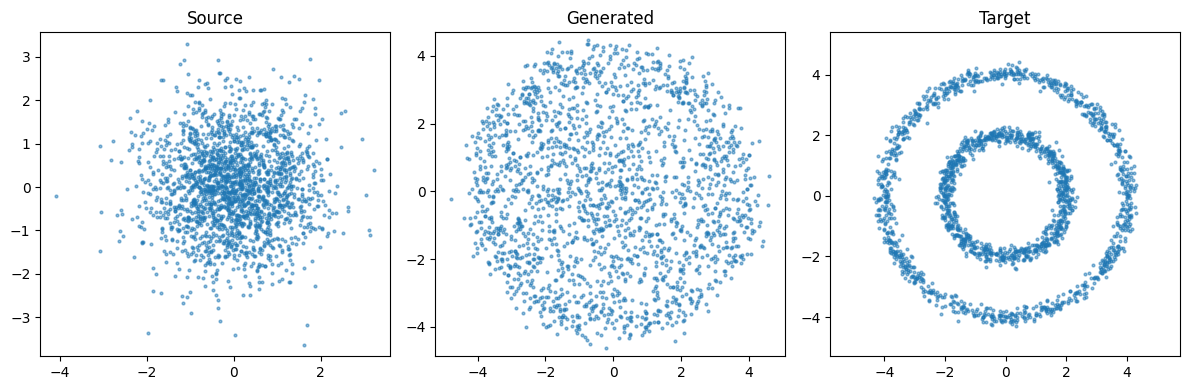

In [8]:
trajectory = sample_trajectory(model, n_samples=2000, steps=100)
source_points = trajectory[0]
final_points = trajectory[-1]
target_points = sample_target(2000, device).cpu()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].scatter(source_points[:, 0], source_points[:, 1], s=4, alpha=0.5)
axes[0].set_title("Source")
axes[0].axis("equal")

axes[1].scatter(final_points[:, 0], final_points[:, 1], s=4, alpha=0.5)
axes[1].set_title("Generated")
axes[1].axis("equal")

axes[2].scatter(target_points[:, 0], target_points[:, 1], s=4, alpha=0.5)
axes[2].set_title("Target")
axes[2].axis("equal")

plt.tight_layout()
plt.show()

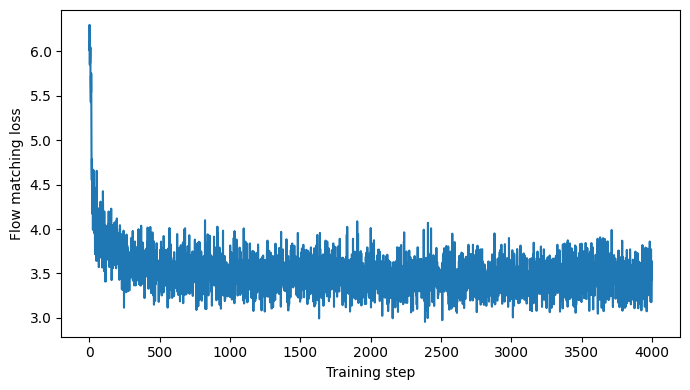

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(history)
plt.xlabel("Training step")
plt.ylabel("Flow matching loss")
plt.tight_layout()
plt.show()

## Rectified Flow Matching on FashionMNIST

The two-dimensional example made the geometry visible, but it is not enough for a course on image generation. We now use the same principle on FashionMNIST. A data image is denoted by $\boldsymbol{x}_1$ and a source noise tensor by $\boldsymbol{x}_0$. Both have shape $1 \times 28 \times 28$. The rectified-flow path is the straight interpolation
:::{math}
\boldsymbol{x}_t = (1-t)\boldsymbol{x}_0 + t\boldsymbol{x}_1,
:::
and the target velocity is $\boldsymbol{x}_1 - \boldsymbol{x}_0$. The network receives the interpolated tensor and the time value, then predicts this velocity field.

This objective is close in implementation style to diffusion training: every minibatch samples random times, a time-conditioned convolutional network processes image-shaped tensors, and the loss is an ordinary mean squared error. The conceptual difference is the target. Diffusion asks the network to predict noise inside a stochastic corruption process. Rectified flow asks the network to predict the deterministic direction that moves an interpolated point toward the data endpoint.

In [10]:
from torch.utils.data import DataLoader
from pathlib import Path
from torchvision import datasets, transforms, utils

image_batch_size = 128
image_size = 28
image_channels = 1
image_base_channels = 64
image_time_dim = 128
image_epochs = 30
image_lr = 2e-4
image_ode_steps = 100
num_workers = 0
project_root = Path.cwd() if (Path.cwd() / "_config.yml").exists() else Path.cwd().parent
DATA_ROOT = project_root / "data"

image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 2.0 * x - 1.0),
])

fashion_train = datasets.FashionMNIST(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=image_transform,
)

fashion_loader = DataLoader(
    fashion_train,
    batch_size=image_batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
)

The images are scaled to $[-1,1]$ for the same practical reason used in the GAN and diffusion notebooks: the source distribution is centered at zero, so the interpolation path is numerically better balanced when the data also live around zero. For visualization and metric computation we later map samples back to $[0,1]$.

## Image Velocity Network

The velocity model is a small U-Net-like network. It is not a diffusion model, because it does not predict noise and it is not trained on a Markov noising chain. Still, the architecture is similar to the diffusion denoiser because the input is an image-shaped tensor and the network must combine local detail with global shape information. The time embedding tells the network where the current tensor lies along the transport path. Early times look more like Gaussian noise, late times look more like FashionMNIST images, and the same network must learn useful velocities across the whole interval.

In [11]:
class ImageResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.time_mlp = nn.Linear(time_dim, out_channels)
        self.norm1 = nn.GroupNorm(8, out_channels)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.activation = nn.SiLU()
        self.residual = (
            nn.Conv2d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.activation(h)
        h = h + self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = self.conv2(h)
        h = self.norm2(h)
        h = self.activation(h)
        return h + self.residual(x)


class ImageVelocityUNet(nn.Module):
    def __init__(self, in_channels=1, base_channels=64, time_dim=128):
        super().__init__()
        self.time_embedding = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.input_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)
        self.down1 = ImageResidualBlock(base_channels, base_channels, time_dim)
        self.downsample1 = nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.down2 = ImageResidualBlock(base_channels * 2, base_channels * 2, time_dim)
        self.downsample2 = nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=4, stride=2, padding=1)
        self.down3 = ImageResidualBlock(base_channels * 4, base_channels * 4, time_dim)

        self.mid = ImageResidualBlock(base_channels * 4, base_channels * 4, time_dim)

        self.upsample2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.up2 = ImageResidualBlock(base_channels * 4, base_channels * 2, time_dim)
        self.upsample1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1)
        self.up1 = ImageResidualBlock(base_channels * 2, base_channels, time_dim)
        self.output_conv = nn.Conv2d(base_channels, in_channels, kernel_size=1)

    def forward(self, x, t):
        t_emb = self.time_embedding(t)

        x0 = self.input_conv(x)
        x1 = self.down1(x0, t_emb)
        x2 = self.downsample1(x1)
        x2 = self.down2(x2, t_emb)
        x3 = self.downsample2(x2)
        x3 = self.down3(x3, t_emb)

        x_mid = self.mid(x3, t_emb)

        x_up = self.upsample2(x_mid)
        x_up = torch.cat([x_up, x2], dim=1)
        x_up = self.up2(x_up, t_emb)
        x_up = self.upsample1(x_up)
        x_up = torch.cat([x_up, x1], dim=1)
        x_up = self.up1(x_up, t_emb)
        return self.output_conv(x_up)


image_flow_model = ImageVelocityUNet(
    in_channels=image_channels,
    base_channels=image_base_channels,
    time_dim=image_time_dim,
).to(device)
image_optimizer = torch.optim.AdamW(image_flow_model.parameters(), lr=image_lr, weight_decay=1e-4)

## Rectified Flow Loss

The loss below is the image-scale version of the conditional flow-matching theorem. For each data minibatch we sample a Gaussian tensor of the same shape, choose a random time for each item, construct the interpolated tensor, and regress the target velocity. Notice that no discriminator, likelihood decoder, or long diffusion chain is needed during training. The learning signal is completely supervised once the endpoint pair and the path have been sampled.

In [12]:
def sample_image_path(x1):
    x0 = torch.randn_like(x1)
    t = torch.rand(x1.size(0), 1, 1, 1, device=x1.device)
    xt = (1.0 - t) * x0 + t * x1
    ut = x1 - x0
    return x0, x1, xt, ut, t.view(x1.size(0), 1)


def rectified_flow_loss(model, x1):
    _, _, xt, ut, t = sample_image_path(x1)
    pred = model(xt, t)
    return F.mse_loss(pred, ut)

## Training the Image Flow

In [13]:
image_history = []

for epoch in tqdm(range(image_epochs), desc="Image rectified-flow epochs"):
    image_flow_model.train()
    running_loss = 0.0

    for x1, _ in tqdm(fashion_loader, desc="train", leave=False):
        x1 = x1.to(device)

        image_optimizer.zero_grad()
        loss = rectified_flow_loss(image_flow_model, x1)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(image_flow_model.parameters(), max_norm=1.0)
        image_optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(fashion_loader)
    image_history.append(epoch_loss)
    print(f"Epoch {epoch + 1:02d} | rectified-flow loss: {epoch_loss:.6f}")

Image rectified-flow epochs:   0%|          | 0/30 [00:00<?, ?it/s]

train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 01 | rectified-flow loss: 0.363246


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 02 | rectified-flow loss: 0.280020


...

Epoch 28 | rectified-flow loss: 0.225609


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 29 | rectified-flow loss: 0.225571


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 30 | rectified-flow loss: 0.224915


The loss is an MSE on velocities, so it is easier to interpret than the adversarial losses in the GAN notebook. A decreasing curve indicates that the model is learning the average transport field along the chosen path. As usual, the scalar is not the whole story. Image quality also depends on the numerical ODE solver and on whether the learned velocity field remains accurate along its own generated trajectories, not only along training interpolants.

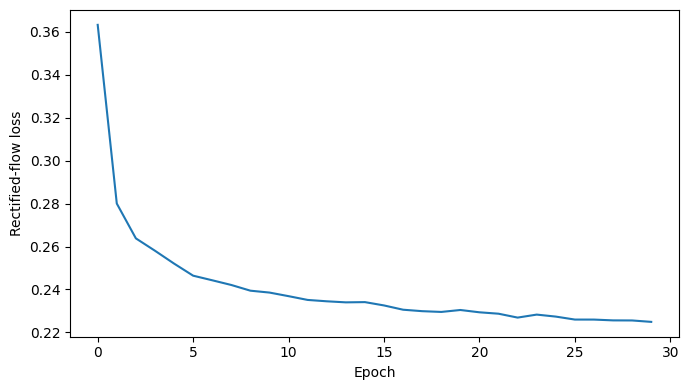

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(image_history)
plt.xlabel("Epoch")
plt.ylabel("Rectified-flow loss")
plt.tight_layout()
plt.show()

## ODE Sampling for Images

Sampling starts from Gaussian noise and integrates the learned ODE from $t=0$ to $t=1$. The code uses a midpoint update rather than the simplest Euler step. This is still transparent enough for teaching, but it usually gives slightly better samples for the same number of function evaluations because the velocity is evaluated near the middle of each interval.

rectified-flow sampling:   0%|          | 0/100 [00:00<?, ?it/s]

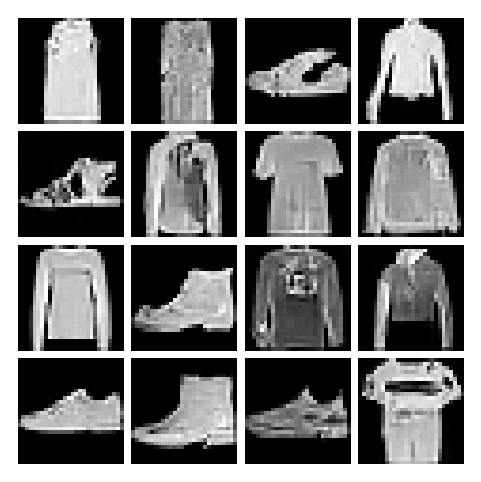

In [15]:
@torch.no_grad()
def sample_rectified_flow(model, n_samples=16, steps=image_ode_steps, show_progress=True):
    model.eval()
    x = torch.randn(n_samples, image_channels, image_size, image_size, device=device)
    dt = 1.0 / steps
    step_iterator = range(steps)
    if show_progress:
        step_iterator = tqdm(step_iterator, desc="rectified-flow sampling", leave=False)

    for i in step_iterator:
        t = torch.full((n_samples, 1), i / steps, device=device)
        v = model(x, t)
        x_mid = x + 0.5 * dt * v
        t_mid = torch.full((n_samples, 1), (i + 0.5) / steps, device=device)
        x = x + dt * model(x_mid, t_mid)

    x = x.clamp(-1.0, 1.0)
    return 0.5 * (x + 1.0).cpu()


image_samples = sample_rectified_flow(image_flow_model, n_samples=16)
image_grid = utils.make_grid(image_samples, nrow=4, pad_value=1.0)
plt.figure(figsize=(6, 6))
plt.imshow(image_grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.show()

When training works, the generated grid should contain recognizable clothing silhouettes rather than only texture or noise. The samples may be less sharp than a heavily tuned diffusion model, but the important comparison is conceptual: rectified flow has produced images by learning a deterministic transport field instead of learning a decoder distribution, an adversarial generator, or a stochastic reverse diffusion chain.

## FID and KID for Rectified Flow

FID and KID are computed exactly as in the previous implementation notebooks. Real FashionMNIST images are converted back to $[0,1]$, grayscale images are repeated across three channels for the Inception feature extractor, and generated samples are drawn from the ODE sampler. The default sample count below is intentionally modest so that the cell can run during teaching. For serious reporting one would use many more samples, cache real features, and state the sample count explicitly.

In [16]:
def prepare_for_inception_metrics(images):
    if images.size(1) == 1:
        images = images.repeat(1, 3, 1, 1)
    return images.clamp(0.0, 1.0)


@torch.no_grad()
def compute_rectified_flow_fid_and_kid(model, real_loader, device, num_samples=1000):
    fid = FrechetInceptionDistance(
        feature=2048,
        normalize=True,
        reset_real_features=False,
    ).set_dtype(torch.float64).to(device)
    kid = KernelInceptionDistance(
        feature=2048,
        subsets=10,
        subset_size=100,
        normalize=True,
        reset_real_features=False,
    ).to(device)

    seen_real = 0
    for real_images, _ in tqdm(real_loader, desc="real metrics", leave=False):
        remaining = num_samples - seen_real
        if remaining <= 0:
            break
        real_images = real_images[:remaining].to(device)
        real_images = 0.5 * (real_images + 1.0)
        real_images = prepare_for_inception_metrics(real_images)
        fid.update(real_images, real=True)
        kid.update(real_images, real=True)
        seen_real += real_images.size(0)

    generated = 0
    pbar = tqdm(total=num_samples, desc="rectified-flow fake metrics", leave=False)
    while generated < num_samples:
        batch_n = min(image_batch_size, num_samples - generated)
        fake_images = sample_rectified_flow(
            model,
            n_samples=batch_n,
            steps=image_ode_steps,
            show_progress=False,
        ).to(device)
        fake_images = prepare_for_inception_metrics(fake_images)
        fid.update(fake_images, real=False)
        kid.update(fake_images, real=False)
        generated += batch_n
        pbar.update(batch_n)
    pbar.close()

    kid_mean, kid_std = kid.compute()
    return {
        "fid": fid.compute().item(),
        "kid_mean": kid_mean.item(),
        "kid_std": kid_std.item(),
    }


rectified_flow_metrics = compute_rectified_flow_fid_and_kid(
    image_flow_model,
    fashion_loader,
    device,
    num_samples=1000,
)
print(rectified_flow_metrics)

c:\Users\tivog\deep-generative-models\.venv\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


real metrics:   0%|          | 0/469 [00:00<?, ?it/s]

rectified-flow fake metrics:   0%|          | 0/1000 [00:00<?, ?it/s]

{'fid': 35.618121200120015, 'kid_mean': 0.010317849926650524, 'kid_std': 0.0028598287608474493}


These scores should be interpreted in the same classroom sense as the VAE, GAN, and diffusion scores. They make the comparison quantitative, but they do not replace visual inspection or a discussion of compute. Rectified flow has a training loop that is direct and stable, like diffusion, but its sampler is an ODE solver whose quality depends on the number of integration steps and on the smoothness of the learned field.

## Practical Discussion

The complete notebook now shows flow matching at two resolutions. In two dimensions, success means that the transported point cloud reaches both rings and that trajectories look smooth rather than erratic. For FashionMNIST, success means that Gaussian noise is transported into recognizable clothing images and that the metric code can compare the resulting image distribution with the dataset using the same FID and KID pattern used elsewhere in the course.

Common failure modes also have different visual signatures. If the two-dimensional example misses one ring, the velocity field may be undertrained or too narrow. If the image model produces low-contrast blobs, the number of epochs may be too small, the velocity network may be underpowered, or the ODE step count may be too low. If the loss decreases but samples remain poor, the model may be accurate on the training interpolation distribution but less accurate along its own generated trajectory. This distinction is central in continuous-time generative modeling: fitting the vector field and numerically realizing the induced transport are related but not identical tasks.

The larger conceptual lesson is that flow matching makes transport explicit. The model learns where probability mass should move, and sampling follows that learned motion from a simple source distribution to the image distribution. That makes this notebook a natural endpoint for the implementation sequence: it reuses neural architectures from diffusion, keeps the stable regression flavor of denoising objectives, and replaces stochastic reverse generation with deterministic transport.